# Lecture 04 Random Forests

Below is a simplified example of how to implement a basic version of a Random Forest from scratch in Python. This example focuses on core concepts such as bootstrapping, decision tree creation, and majority voting.

We'll make the following assumptions:
- The trees will be simple decision stumps (trees with a depth of 1).
- We'll bootstrap the data for each tree.
- We'll use majority voting for classification.

Predictions: [4146.87 4146.87 4146.87 ... 4146.87 4146.87 4146.87]


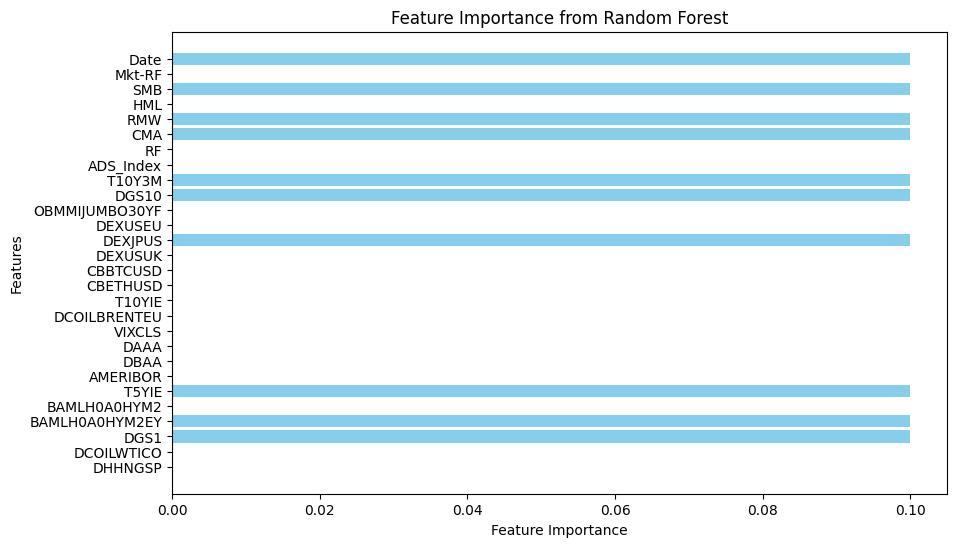

In [3]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Decision Tree Class (unchanged)
class DecisionTree:
    def __init__(self, max_features=None):
        self.max_features = max_features
        self.split_feature = None
        self.split_value = None
        self.left_prediction = None
        self.right_prediction = None

    def fit(self, X, y):
        n_features = X.shape[1]
        feature_indices = np.random.choice(n_features, self.max_features, replace=False)
        best_gini = float("inf")

        for feature in feature_indices:
            values = X[:, feature]
            thresholds = np.unique(values)
            for threshold in thresholds:
                left_mask = values < threshold
                right_mask = ~left_mask
                gini = self._gini_impurity(y[left_mask], y[right_mask])
                if gini < best_gini:
                    best_gini = gini
                    self.split_feature = feature
                    self.split_value = threshold
                    self.left_prediction = self._majority_vote(y[left_mask])
                    self.right_prediction = self._majority_vote(y[right_mask])

    def predict(self, X):
        predictions = []
        for row in X:
            if row[self.split_feature] < self.split_value:
                predictions.append(self.left_prediction)
            else:
                predictions.append(self.right_prediction)
        return np.array(predictions)

    def _gini_impurity(self, left, right):
        n = len(left) + len(right)
        if n == 0:
            return 0
        left_score = 1.0 - sum((np.sum(left == c) / len(left)) ** 2 for c in np.unique(left))
        right_score = 1.0 - sum((np.sum(right == c) / len(right)) ** 2 for c in np.unique(right))
        return (len(left) * left_score + len(right) * right_score) / n

    def _majority_vote(self, y):
        if len(y) == 0:
            return 0
        return Counter(y).most_common(1)[0][0]


# Random Forest Class
class RandomForest:
    def __init__(self, n_estimators=10, max_features=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.trees = []
        self.feature_importances_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        feature_importances = np.zeros(n_features)

        for _ in range(self.n_estimators):
            sample_indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[sample_indices], y[sample_indices]
            tree = DecisionTree(max_features=self.max_features)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

            if tree.split_feature is not None:
                feature_importances[tree.split_feature] += 1

        self.feature_importances_ = feature_importances / sum(feature_importances)

    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        final_predictions = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0], axis=0, arr=tree_predictions)
        return final_predictions


if __name__ == "__main__":
    data = pd.read_csv("INFO6105_FeatureMart.csv")
    label_column = "SP500"
    feature_columns = [col for col in data.columns if col != label_column]

    X = data[feature_columns].values
    y = data[label_column].values

    clf = RandomForest(n_estimators=10, max_features=3)
    clf.fit(X, y)

    predictions = clf.predict(X)
    print("Predictions:", predictions)

    feature_names = feature_columns
    feature_importances = clf.feature_importances_

    plt.figure(figsize=(10, 6))
    plt.barh(feature_names, feature_importances, color="skyblue")
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    plt.title("Feature Importance from Random Forest")
    plt.gca().invert_yaxis()
    plt.show()


Key Steps:
- Decision Stump: This is a simple classifier that looks for a single best feature and threshold to split the data.
- Random Forest: This class builds multiple decision stumps (trees with depth 1), bootstraps the data, and aggregates the results from all trees using majority voting.

This code is quite basic and can be extended to include more sophisticated decision trees, hyperparameters, and splitting criteria. For instance:
- You can replace DecisionStump with a more advanced DecisionTree class.
- You can add criteria such as Gini impurity for feature selection and threshold splitting.